## 01. MNIST数据集分类练习

> 本练习使用PyTorch完成MNIST数据集分类的练习，熟悉PyTorch的基本使用流程。

In [1]:
%matplotlib inline
import torch
import numpy as np
from matplotlib import pyplot as plt

torch.set_printoptions(edgeitems=2)
torch.manual_seed(123456)

### 1.1 加载数据

In [2]:
from datetime import datetime

from torch import nn
from torchvision import datasets
from torchvision import transforms

In [3]:
# 数据存放的路径
data_path = "../../data/torchvision/"

In [4]:
!ls ../../data/torchvision | grep MNIST

MNIST


In [5]:
# 实例化一个数据，用于训练，设置了donwload=True，当数据不存在的时候会自动下载
mnist = datasets.MNIST(data_path, train=True, download=True)

In [6]:
mnist

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../../data/torchvision/
    Split: Train

In [7]:
type(mnist).__mro__

(torchvision.datasets.mnist.MNIST,
 torchvision.datasets.vision.VisionDataset,
 torch.utils.data.dataset.Dataset,
 typing.Generic,
 object)

In [8]:
# 可以看到数据集中的每一项是一个元组
type(mnist[0])

tuple

In [9]:
# 元组中：第1项是Image类型，第2项是int数据(0-9的数字)
type(mnist[0][0]), type(mnist[0][1])

(PIL.Image.Image, int)

In [10]:
mnist[0][0]

**展示前面20张图片：** 2行10列展示

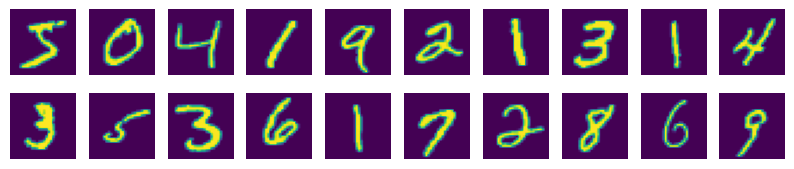

In [11]:
count = 20
column = 10

fig, axs = plt.subplots(2, 10, figsize=(10, 2))
# print(fig, axs, len(axs))


for i in range(count):
    r = i // column
    c = i % column
    axs[r][c].imshow(mnist[i][0])
    axs[r][c].axis('off')
plt.show()

**加载数据，并转换为张量**

In [12]:
to_tensor = transforms.ToTensor()

In [13]:
img_t = to_tensor(mnist[0][0])
type(img_t)

torch.Tensor

In [14]:
# 加载MNIST数据集，并转换为张量
tensor_mnist = datasets.MNIST(data_path, train=True, download=True, transform=to_tensor)

In [15]:
tensor_mnist

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../../data/torchvision/
    Split: Train
    StandardTransform
Transform: ToTensor()

In [16]:
# 可以看到数据集的每一项是个元组，第一项是Tensor，第二项是数字(label: 0-9)
type(tensor_mnist[0])

tuple

In [17]:
type(tensor_mnist[0][0]), type(tensor_mnist[0][1])

(torch.Tensor, int)

In [18]:
# 查看张量的形状
tensor_mnist[0][0].shape

torch.Size([1, 28, 28])

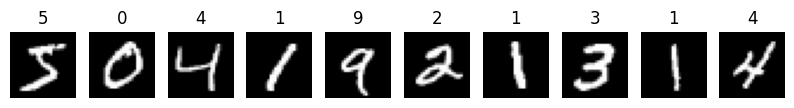

In [19]:
# 展示10行图片
count = 10
fig, axs = plt.subplots(1, 10, figsize=(10, 2))
for i in range(count):
    axs[i].imshow(tensor_mnist[i][0].permute(1,2,0), cmap="gray")
    axs[i].set_title("{}".format(tensor_mnist[i][1]))
    axs[i].axis('off')
plt.show()

### 1.2 数据取样

In [20]:
# 训练取样
train_loader = torch.utils.data.DataLoader(tensor_mnist, batch_size=128, shuffle=True)

In [21]:
# 验证取样
tensor_mnist_val = datasets.MNIST(data_path, train=False, download=True, transform=to_tensor)
val_loader = torch.utils.data.DataLoader(tensor_mnist_val, batch_size=128, shuffle=True)

### 1.3 编写模型

In [22]:
class NetModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.sequential = nn.Sequential(
            nn.Linear(28*28, 392),
            nn.ReLU(),
            nn.Linear(392, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, input):
        input = self.flatten(input)
        output = self.sequential(input)
        return output

In [23]:
28*28

784

In [24]:
_ * 0.5

392.0

### 1.4 训练循环

In [25]:
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader, device="cpu"):
    
    # 我们遍历从1到，n_epochs
    for epoch in range(1, n_epochs + 1):
        # 初始化训练损失为0.0
        loss_train = 0.0

        # 从数据加载器中获取到图像和图像对应的标签
        for imgs, labels in train_loader:
            if imgs.device != device:
                # to device
                imgs = imgs.to(device)
                labels = labels.to(device)
            
            # 调用模型
            outputs = model(imgs)
            # 计算损失
            loss = loss_fn(outputs, labels)
            # print(loss)

            # 去掉最后一轮的梯度
            optimizer.zero_grad()
            # 执行backward(0，计算所有我们希望网络学习的参数的梯度
            loss.backward()
            # 更新模型
            optimizer.step()
            
            # 对整个循环遍历中得到的损失求和
            loss_train += loss.item()

        # 输出相关信息
        if epoch == 1 or epoch % 2 == 0:
            print("{} Epoch {}, Trainning loss {}".format(
                datetime.now(),
                epoch,
                loss_train / len(train_loader)
            ))

### 1.5 执行训练循环


In [26]:
device = torch.device("cuda") if torch.cuda.is_available() else \
         torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [27]:
device

device(type='mps')

In [28]:
model = NetModel()
model = model.to(device)

In [29]:
model

NetModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (sequential): Sequential(
    (0): Linear(in_features=784, out_features=392, bias=True)
    (1): ReLU()
    (2): Linear(in_features=392, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [30]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [31]:
loss_fn = nn.CrossEntropyLoss()

In [32]:
training_loop(
    n_epochs=10, optimizer=optimizer, model=model,
    loss_fn=loss_fn, train_loader=train_loader,
    device=device,
)

2024-05-29 17:42:12.952574 Epoch 1, Trainning loss 2.101376436158284
2024-05-29 17:42:15.858792 Epoch 2, Trainning loss 1.3392328317485638
2024-05-29 17:42:21.665287 Epoch 4, Trainning loss 0.6054944080838771
2024-05-29 17:42:27.457629 Epoch 6, Trainning loss 0.43742967408094835
2024-05-29 17:42:33.230400 Epoch 8, Trainning loss 0.37033784710395057
2024-05-29 17:42:38.945657 Epoch 10, Trainning loss 0.3348878795531259


### 1.6 计算准确率

In [33]:
# 得到一组图片和标签
for imgs, labels in train_loader:
    if imgs.device != device:
        print("to device")
        # to device
        imgs = imgs.to(device)
        labels = labels.to(device)
        break
        

to device


In [34]:
imgs.shape, labels.shape

(torch.Size([128, 1, 28, 28]), torch.Size([128]))

In [35]:
labels[0]

tensor(9, device='mps:0')

In [36]:
# 计算模型的输出
outputs = model(imgs)

In [37]:
outputs.shape, type(outputs)

(torch.Size([128, 10]), torch.Tensor)

In [38]:
argmax = outputs.argmax(1)  # 获取dim=1轴最大值的索引
argmax

tensor([9, 2, 9, 3, 8, 1, 2, 2, 6, 9, 6, 9, 4, 8, 2, 9, 0, 3, 2, 8, 9, 4, 5, 6,
        8, 7, 4, 8, 6, 0, 0, 2, 1, 3, 9, 2, 9, 3, 7, 2, 1, 1, 4, 6, 8, 4, 0, 5,
        2, 9, 5, 5, 7, 9, 0, 3, 1, 1, 3, 9, 3, 3, 6, 9, 1, 5, 7, 4, 4, 6, 5, 1,
        9, 2, 9, 3, 6, 9, 6, 3, 4, 9, 0, 8, 5, 1, 8, 3, 8, 9, 8, 5, 8, 8, 3, 3,
        8, 1, 3, 3, 2, 5, 7, 1, 7, 7, 3, 7, 5, 6, 6, 2, 1, 3, 5, 3, 8, 1, 4, 0,
        6, 5, 2, 9, 7, 7, 8, 4], device='mps:0')

In [39]:
labels

tensor([9, 2, 9, 3, 8, 1, 2, 2, 6, 9, 6, 9, 2, 8, 2, 9, 0, 3, 2, 8, 9, 4, 5, 6,
        8, 7, 4, 8, 6, 0, 0, 2, 1, 3, 9, 2, 9, 3, 7, 2, 1, 1, 4, 6, 8, 4, 0, 5,
        2, 9, 5, 5, 7, 9, 5, 3, 1, 1, 3, 9, 3, 3, 6, 9, 8, 5, 7, 4, 4, 6, 5, 1,
        9, 0, 9, 3, 6, 9, 6, 3, 4, 9, 0, 8, 5, 1, 0, 3, 8, 9, 5, 5, 5, 8, 3, 3,
        8, 1, 3, 3, 2, 5, 7, 7, 7, 7, 3, 7, 5, 6, 6, 2, 1, 3, 5, 3, 8, 1, 4, 0,
        6, 5, 2, 9, 7, 7, 8, 4], device='mps:0')

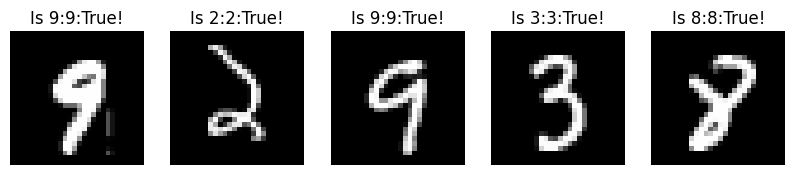

In [40]:
# 显示第1张图片
# img = imgs[1].clone().to("cpu")
# plt.imshow(img.permute(1,2,0), cmap="gray")
# plt.show()

# 显示10张图片
count = 5
fig, axs = plt.subplots(1, count, figsize=(10, 2))
for i in range(count):
    img = imgs[i].clone().to("cpu")
    axs[i].imshow(img.permute(1,2,0), cmap="gray")
    axs[i].set_title("Is {}:{}:{}!".format(labels[i], argmax[i],labels[i] == argmax[i]))
    axs[i].axis('off')
plt.show()

In [41]:
# 判断其是否等于标签，我们标签也是0-1的
outputs.argmax(1) == labels

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True, False,  True,  True,  True,  True,  True,
         True,  True,  True, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True, False,  True,  True,  True,
        False,  True, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True],

In [42]:
# 把True转化为0/1
(outputs.argmax(1) == labels).type(torch.float)

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1.,
        1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
        0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1.], device='mps:0')

In [43]:
# 计算准确率
accracy = (outputs.argmax(1) == labels).type(torch.float).sum().item() / len(outputs)
accracy

0.9375

In [44]:
# 预测准确率
def accuracy(preddata, labels):
    pred = torch.argmax(preddata, 1)
    rights = (pred == labels).type(torch.float).sum().item()
    return rights / len(labels)

In [45]:
accuracy(outputs, labels)

0.9375

### 1.7 训练循环优化:加入准确率

In [46]:
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader, val_loader, device="cpu"):
    
    # 我们遍历从1到，n_epochs
    for epoch in range(1, n_epochs + 1):
        # 初始化训练损失为0.0
        loss_train = 0.0

        # 从数据加载器中获取到图像和图像对应的标签
        for imgs, labels in train_loader:
            if imgs.device != device:
                # to device
                imgs = imgs.to(device)
                labels = labels.to(device)
            
            # 调用模型
            outputs = model(imgs)
            # 计算损失
            loss = loss_fn(outputs, labels)
            # print(loss)

            # 去掉最后一轮的梯度
            optimizer.zero_grad()
            # 执行backward(0，计算所有我们希望网络学习的参数的梯度
            loss.backward()
            # 更新模型
            optimizer.step()
            
            # 对整个循环遍历中得到的损失求和
            loss_train += loss.item()         

        # 输出相关信息
        if epoch == 1 or epoch % 5 == 0:
            # 计算训练集的准确率
            accuracy_train = accuracy(outputs, labels)

            # 执行model.eval()
            # model.eval()
            
            # 测试集的准确率
            accuracy_val_list = []
            for imgs, labels in val_loader:
                if imgs.device != device:
                    # to device
                    imgs = imgs.to(device)
                    labels = labels.to(device)
                outputs = model(imgs)
                accuracy_val = accuracy(outputs, labels)
                accuracy_val_list.append(accuracy_val)
                # print(accuracy_val)

            # 计算验证集的准确率
            accuracy_val = sum(accuracy_val_list) / len(accuracy_val_list)
                
            print("{} Epoch {}, Trainning loss {}, Train accuracy: {:.3f}%, Val accuracy: {:.3f}%".format(
                datetime.now(),
                epoch,
                loss_train / len(train_loader),
                accuracy_train * 100,
                accuracy_val * 100,
            ))

In [47]:
# 执行训练：参数准备
device = torch.device("cuda:0") if torch.cuda.is_available() else \
         torch.device("mps:0") if torch.backends.mps.is_available() else torch.device("cpu")

model = NetModel()
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

In [48]:
# 执行训练
training_loop(
    n_epochs=50, optimizer=optimizer, model=model,
    loss_fn=loss_fn, 
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
)

2024-05-29 17:42:42.614470 Epoch 1, Trainning loss 0.2349649508322861, Train accuracy: 91.667%, Val accuracy: 95.530%
2024-05-29 17:42:55.175643 Epoch 5, Trainning loss 0.09088260913218088, Train accuracy: 96.875%, Val accuracy: 96.272%
2024-05-29 17:43:10.815554 Epoch 10, Trainning loss 0.06869648235749755, Train accuracy: 97.917%, Val accuracy: 96.578%
2024-05-29 17:43:26.388464 Epoch 15, Trainning loss 0.05906945638769894, Train accuracy: 100.000%, Val accuracy: 97.182%
2024-05-29 17:43:42.139581 Epoch 20, Trainning loss 0.041492100233323004, Train accuracy: 100.000%, Val accuracy: 97.439%
2024-05-29 17:43:58.687225 Epoch 25, Trainning loss 0.04556637062511006, Train accuracy: 100.000%, Val accuracy: 96.756%
2024-05-29 17:44:15.239900 Epoch 30, Trainning loss 0.04090697664316912, Train accuracy: 97.917%, Val accuracy: 97.409%
2024-05-29 17:44:31.766413 Epoch 35, Trainning loss 0.04149743209927304, Train accuracy: 98.958%, Val accuracy: 97.449%
2024-05-29 17:44:47.871307 Epoch 40, Tr

### 1.8 保存模型

In [49]:
!mkdir -p ../../models/prictice01

In [50]:
model_path = "../../models/prictice01/01-mist.pth"

In [51]:
torch.save(model, model_path)

In [52]:
! ls ../../models/prictice01

01-mist.pth


### 1.9 加载模型

In [53]:
model2 = torch.load(model_path)

In [54]:
# 设置模型为评估模型
model2.eval()

NetModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (sequential): Sequential(
    (0): Linear(in_features=784, out_features=392, bias=True)
    (1): ReLU()
    (2): Linear(in_features=392, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [55]:
# 得到一组图片和标签
for imgs, labels in train_loader:
    if imgs.device != device:
        print("to device")
        # to device
        imgs = imgs.to(device)
        labels = labels.to(device)
        break

to device


In [56]:
imgs.shape, labels.shape

(torch.Size([128, 1, 28, 28]), torch.Size([128]))

In [57]:
outputs = model2(imgs)
outputs.shape

torch.Size([128, 10])

In [58]:
# 计算准确率
(outputs.argmax(1) == labels).type(torch.float).sum().item() / len(outputs) * 100

99.21875